# 서울 5060 남성 1인가구는 경제·지역적으로 취약하다

**EDA 3단계** | 2단계에서 넘어온 질문에 답한다

**분석 흐름**
1. 노동 취약성 — 서울 5060 남성은 취업해도 단순노무 전국 1위
2. 지역 집중 — 교육+관계해체 지표로 취약점수 → 동북권 집중
3. 행정 검증 — 취약 등급이 높을수록 수급밀도 단조 증가
4. 축별 분해 — 교육축·관계해체축 각각 독립적으로 경제적 취약과 연동

**데이터**
- 2020 인구주택총조사: 혼인상태·교육정도(시군구, 5060남성) / 직업·경제활동(시도)
- 2024.05 서울시 생계급여 수급자 (자치구)

In [103]:
# -*- coding: utf-8 -*-
"""03단계 EDA 차트 4장 생성 — 새 파이프라인"""
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os, re, glob

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ACCENT    = '#C0392B'
OTHER_COLOR = '#A8C6DF'
BG_COLOR  = '#FFFFFF'
GRADE_COLORS = {'매우강함':'#C0392B', '조금강함':'#D4756B',
                '조금약함':'#A8C6DF', '매우약함':'#1B3A5C'}
GRADE_ORDER = ['매우약함', '조금약함', '조금강함', '매우강함']

DATA_DIR = '../Data/EDA/'
GEO_PATH = '../Data/seoul_dong.geojson'
OUT_DIR = '../Outputs'
os.makedirs(OUT_DIR, exist_ok=True)

GU25 = ['종로구','중구','용산구','성동구','광진구','동대문구','중랑구','성북구',
        '강북구','도봉구','노원구','은평구','서대문구','마포구','양천구','강서구',
        '구로구','금천구','영등포구','동작구','관악구','서초구','강남구','송파구','강동구']
SIDO17 = ['서울특별시','부산광역시','대구광역시','인천광역시','광주광역시','대전광역시',
          '울산광역시','세종특별자치시','경기도','강원도','충청북도','충청남도',
          '전라북도','전라남도','경상북도','경상남도','제주특별자치도']
SIDO_SHORT = {'서울특별시':'서울','부산광역시':'부산','대구광역시':'대구','인천광역시':'인천',
              '광주광역시':'광주','대전광역시':'대전','울산광역시':'울산','세종특별자치시':'세종',
              '경기도':'경기','강원도':'강원','충청북도':'충북','충청남도':'충남',
              '전라북도':'전북','전라남도':'전남','경상북도':'경북','경상남도':'경남',
              '제주특별자치도':'제주'}
AGE_5060 = ['50~54','55~59','60~64']
AGE_5060_EXT = ['50~54','55~59','60~64','50~54세','55~59세','60~64세']

# === 데이터 로딩 ===
def load_sigungu(filename):
    raw = pd.read_excel(DATA_DIR + filename, header=None)
    raw[0] = raw[0].ffill(); raw[1] = raw[1].ffill()
    raw[0] = raw[0].astype(str).str.replace('\u3000','',regex=False).str.strip()
    for c in range(3, raw.shape[1]):
        raw[c] = pd.to_numeric(raw[c], errors='coerce')
    return raw

def sum_5060_gu(raw, sex):
    sub = raw[(raw[1]==sex)&(raw[2].isin(AGE_5060))&(raw[0].isin(GU25))]
    return raw.loc[sub.index].groupby(0)[list(range(3,raw.shape[1]))].sum().reindex(GU25)

def load_sido(filename):
    raw = pd.read_excel(DATA_DIR + filename, header=None)
    raw[0] = raw[0].ffill(); raw[1] = raw[1].ffill()
    for c in range(3, raw.shape[1]):
        raw[c] = pd.to_numeric(raw[c], errors='coerce')
    return raw

def sum_5060_sido(raw, sex):
    sub = raw[(raw[1]==sex)&(raw[2].isin(AGE_5060_EXT))&(raw[0].isin(SIDO17))]
    return sub.groupby(0)[list(range(3,raw.shape[1]))].sum().reindex(SIDO17)

mar_m = sum_5060_gu(load_sigungu('성별_연령별_혼인상태별_1인가구_일반가구_시군구.xlsx'), '남자')
edu_m = sum_5060_gu(load_sigungu('성별_연령별_교육정도별_1인가구_일반가구_시군구.xlsx'), '남자')
job_m_sido = sum_5060_sido(load_sido('성별_연령별_직업별_1인가구_15세_이상_일반가구_시도.xlsx'), '남자')

with open(DATA_DIR + '성별_연령별_경제활동상태별_1인가구사유별_가구_시도.xls', 'r', encoding='euc-kr') as f:
    _content = f.read()
_rows = [re.findall(r'<Data[^>]*>([^<]*)</Data>', r) for r in re.findall(r'<Row[^>]*>(.*?)</Row>', _content, re.S)]
econ_df = pd.DataFrame([r for r in _rows if len(r)==7], columns=['region','sex','age','econ','item','unit','val'])
econ_df['val'] = pd.to_numeric(econ_df['val'], errors='coerce')
def econ_5060(sex='남자'):
    sub = econ_df[(econ_df['sex']==sex)&(econ_df['age'].isin(AGE_5060_EXT))&(econ_df['item']=='1인가구-계')&(econ_df['region'].isin(SIDO17))]
    return sub.pivot_table(index='region',columns='econ',values='val',aggfunc='sum').reindex(SIDO17)

raw_w = pd.read_excel(DATA_DIR + '서울시_국민기초생활_수급자_동별_현황(202405).xlsx', header=None)
welfare = {}; cur, last_b = None, ''
for idx in range(3, len(raw_w)):
    c0,b,age,val = raw_w.iloc[idx,0],raw_w.iloc[idx,1],raw_w.iloc[idx,2],raw_w.iloc[idx,4]
    if pd.notna(c0) and str(c0).endswith('구'): cur=str(c0); welfare.setdefault(cur,0)
    if pd.notna(b): last_b=str(b)
    if cur and pd.notna(age) and '18~64' in str(age) and pd.notna(val) and '생계' in last_b:
        welfare[cur]+=int(val)
welfare_gu = pd.Series(welfare).reindex(GU25)

hh_file = glob.glob(DATA_DIR + '*2019-2024*')[0]
with open(hh_file, 'r', encoding='euc-kr') as f:
    _hh_content = f.read()
_hh_dv = re.findall(r'<Data[^>]*>([^<]*)</Data>', _hh_content)
def _extract_hh(gender, hh_type):
    result={}
    for i,d in enumerate(_hh_dv):
        if d in GU25 and i+9<len(_hh_dv):
            if _hh_dv[i+1]==gender and _hh_dv[i+2]=='합계' and _hh_dv[i+3]==hh_type:
                result[d]=[int(_hh_dv[i+5+k]) for k in range(5)]
    return pd.DataFrame(result, index=[2020,2021,2022,2023,2024]).T
general_gu = _extract_hh('계','일반가구')[2024].reindex(GU25)

gdf = gpd.read_file(GEO_PATH)
gdf_gu = gdf.dissolve(by='sggnm').reset_index()

# === 거처·점유 (전체 1인가구 기준) ===
res_raw = load_sigungu('거처의_종류별_사용방수별_점유형태별_1인가구_일반가구_시군구.xlsx')
res_sub = res_raw[(res_raw[1] == '계') & (res_raw[2] == '계') & (res_raw[0].isin(GU25))]
res_gu = res_raw.loc[res_sub.index].groupby(0)[list(range(3, res_raw.shape[1]))].sum().reindex(GU25)

# === 프로파일 ===
prof = pd.DataFrame(index=GU25)
prof['이혼율'] = mar_m[7]/mar_m[3]*100
prof['사별율'] = mar_m[6]/mar_m[3]*100
prof['고졸이하율'] = (edu_m[4]+edu_m[5]+edu_m[6])/edu_m[3]*100
prof['취약점유율'] = (res_gu[7] + res_gu[8]) / res_gu[3] * 100  # 무보증월세+사글세 (전체1인가구)
prof['수급밀도'] = welfare_gu/general_gu*100

# 3지표 취약점수
FEAT = ['이혼율','사별율','고졸이하율','취약점유율']
z = (prof[FEAT]-prof[FEAT].mean())/prof[FEAT].std()
prof['취약점수'] = z.sum(axis=1)
prof['취약등급'] = pd.qcut(prof['취약점수'], 4, labels=GRADE_ORDER)
prof = prof.round(2)

# 시도 프로파일
profile_sido = pd.DataFrame(index=SIDO17)
profile_sido['단순노무_비중'] = job_m_sido[12]/job_m_sido[3]*100
ec = econ_5060('남자')
profile_sido['미취업_비중'] = ec['일하지 않았음']/ec.sum(axis=1)*100
profile_sido.index = [SIDO_SHORT[s] for s in profile_sido.index]
profile_sido = profile_sido.round(1)

print('데이터 준비 완료')
print(f"서울 5060 남성 1인가구: {int(mar_m[3].sum()):,}명")
print(f"단순노무: {profile_sido.loc['서울','단순노무_비중']}% (1위/17)")
print(f"4지표 취약점수 r(수급밀도): {np.corrcoef(prof['취약점수'], prof['수급밀도'])[0,1]:.3f}")

# ============================================================

c:\Users\Lisa\anaconda3\envs\pythonProject1\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\Lisa\anaconda3\envs\pythonProject1\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\Lisa\anaconda3\envs\pythonProject1\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


데이터 준비 완료
서울 5060 남성 1인가구: 137,463명
단순노무: 18.9% (1위/17)
4지표 취약점수 r(수급밀도): 0.582


c:\Users\Lisa\anaconda3\envs\pythonProject1\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


---
## 분석 1 — 노동 취약성: 서울은 일자리가 가장 많은 도시이지만

5060 남성 1인가구 취업자 중 단순노무 비중을 17개 시도와 비교한다.

In [104]:
# 차트 1: 노동 취약성 산점도
# ============================================================
x = profile_sido['미취업_비중']; y = profile_sido['단순노무_비중']
fig, ax = plt.subplots(figsize=(9,7), facecolor=BG_COLOR); ax.set_facecolor(BG_COLOR)
ax.axvline(x.mean(), color='#CED4DA', ls='--', lw=1)
ax.axhline(y.mean(), color='#CED4DA', ls='--', lw=1)
for sido in profile_sido.index:
    is_s = sido=='서울'
    ax.scatter(x[sido],y[sido],s=220 if is_s else 110, c=ACCENT if is_s else OTHER_COLOR,
               alpha=0.9 if is_s else 0.6, edgecolors='white',lw=1.5,zorder=3)
    ax.annotate(sido,(x[sido],y[sido]),xytext=(6,6),textcoords='offset points',
                fontsize=10 if is_s else 8, fontweight='bold' if is_s else 'normal',
                color=ACCENT if is_s else '#2C3E50')
ax.set_xlabel('미취업 비중 (%)'); ax.set_ylabel('단순노무 비중 (%)')
ax.set_title('서울 5060 남성 1인가구는 취업해도 단순노무 비중이 전국 1위다 (2020)', fontsize=13, fontweight='bold', pad=15)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/03_labor_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.close()
print('\n[차트1] 03_labor_scatter.png 저장')

# ============================================================


[차트1] 03_labor_scatter.png 저장


---
## 분석 2 — 지역 집중: 취약성은 서울 안에서 어디에 쏠려 있는가

교육(고졸이하율) + 관계해체(이혼율·사별율) 3개 지표를 z-score 표준화 후 합산해
'종합 취약 점수'를 만들고 25개 자치구를 4등급으로 분류한다.

> 3개 지표 모두 5060 남성 1인가구 기준 (2020 인구총조사).

In [105]:
# 차트 2: 지역 집중 (지도+막대)
# ============================================================
fig, axes = plt.subplots(1,2,figsize=(15,7.5),facecolor=BG_COLOR)
ax = axes[0]; ax.set_facecolor(BG_COLOR)
gm = gdf_gu.copy()
gm['grade'] = gm['sggnm'].map(prof['취약등급'].astype(str))
cent = gm.to_crs(epsg=5179).geometry.centroid.to_crs(gm.crs)
for g in GRADE_ORDER:
    sub = gm[gm['grade']==g]
    if len(sub): sub.plot(ax=ax, color=GRADE_COLORS[g], edgecolor='white', linewidth=0.6)
for (_,row),cx,cy in zip(gm.iterrows(),cent.x,cent.y):
    ax.text(cx,cy,row['sggnm'][:-1],ha='center',va='center',fontsize=7,fontweight='bold',color='white')
ax.set_title('취약성은 서울 전역이 아니라 특정 자치구에 집중된다', fontsize=13, fontweight='bold', pad=10)
ax.axis('off')
handles = [plt.Rectangle((0,0),1,1,fc=GRADE_COLORS[g]) for g in GRADE_ORDER[::-1]]
ax.legend(handles, GRADE_ORDER[::-1], frameon=False, fontsize=9, loc='lower left')

ax = axes[1]; ax.set_facecolor(BG_COLOR)
s = prof['취약점수'].sort_values()
colors = [GRADE_COLORS[prof.loc[gu,'취약등급']] for gu in s.index]
bars = ax.barh(s.index, s.values, color=colors, alpha=0.95)
for bar,gu in zip(bars,s.index):
    w=bar.get_width()
    ax.text(w+(0.12 if w>=0 else -0.12),bar.get_y()+bar.get_height()/2,f'{w:+.1f}',
            va='center',ha='left' if w>=0 else 'right',fontsize=8,fontweight='bold')
ax.axvline(x=0,color='#2C3E50',lw=0.8)
ax.set_xlabel('종합 취약 점수 (4개 지표 z-score 합산)')
ax.set_title('4개 지표(이혼·사별·고졸이하·취약점유)를 합산한 자치구별 취약점수', fontsize=13, fontweight='bold', pad=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/03_district_grade.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.close()
print('[차트2] 03_district_grade.png 저장')
for g in GRADE_ORDER[::-1]:
    print(f"  [{g}] {', '.join(prof[prof['취약등급']==g].index)}")

# ============================================================

[차트2] 03_district_grade.png 저장
  [매우강함] 동대문구, 중랑구, 강북구, 도봉구, 구로구, 영등포구
  [조금강함] 중구, 광진구, 노원구, 양천구, 금천구, 강동구
  [조금약함] 성북구, 은평구, 강서구, 동작구, 관악구, 송파구
  [매우약함] 종로구, 용산구, 성동구, 서대문구, 마포구, 서초구, 강남구


---
## 분석 3 — 행정 검증: 취약 등급이 높을수록 복지 수급도 늘어나는가

통계 지표로 만든 '취약 등급'이 실제 행정 현실(생계급여 수급)과 맞물리는지 본다.
등급별 평균 수급밀도가 매우약함 → 매우강함으로 단조롭게 증가하면,
우리가 만든 등급이 허상이 아니라는 근거가 된다.

> 2020 인구총조사(1인가구)와 2024 수급자 데이터는 연도가 다르다.
> 자치구의 '구조적 위치'를 비교하는 용도이며 시점 일치 분석이 아니다.

In [106]:
# 차트 3: 행정 검증 (단조증가 + 산점도)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR,
                         gridspec_kw={"width_ratios": [1, 1.3]})

# --- (좌) 등급별 수급밀도 단조증가 ---
ax = axes[0]; ax.set_facecolor(BG_COLOR)
means = prof.groupby("취약등급")["수급밀도"].mean().reindex(GRADE_ORDER)
bars = ax.bar(GRADE_ORDER, means.values,
              color=[GRADE_COLORS[g] for g in GRADE_ORDER], alpha=0.95, width=0.6)
for bar, v in zip(bars, means.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.07, f"{v:.2f}%",
            ha="center", fontsize=11, fontweight="bold")
ax.plot(range(4), means.values, color="#2C3E50", lw=1.5, ls="--", marker="o", markersize=5, zorder=3)
ax.set_ylabel("평균 생계급여 수급밀도 (%, 일반가구 대비)")
ax.set_title("취약 4개 그룹별 수급밀도가 점진적으로 상승한다",
             fontsize=13, fontweight="bold", pad=15)
ax.set_ylim(0, means.max()*1.25)
ax.spines[["top","right"]].set_visible(False)

# --- (우) 산점도: 취약점수 vs 수급밀도 ---
ax = axes[1]; ax.set_facecolor(BG_COLOR)
x = prof["취약점수"]; y = prof["수급밀도"]
z_fit = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, np.poly1d(z_fit)(xs), "--", color="#868E96", linewidth=1.3, alpha=0.85)
for gu in GU25:
    g = prof.loc[gu, "취약등급"]
    ax.scatter(x[gu], y[gu], s=150, c=GRADE_COLORS[g], alpha=0.9,
               edgecolors="white", linewidth=1.5, zorder=3)
    ax.annotate(gu, (x[gu], y[gu]), xytext=(5, 4), textcoords="offset points",
                fontsize=7.5, fontweight="bold", color="#2C3E50")
r_full = np.corrcoef(x, y)[0, 1]
ax.text(0.03, 0.97, f"피어슨 r = {r_full:.2f}", transform=ax.transAxes,
        fontsize=12, fontweight="bold", va="top",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#CED4DA"))
handles = [plt.Line2D([0],[0], marker="o", color="w", markersize=10,
           markerfacecolor=GRADE_COLORS[g], label=g) for g in GRADE_ORDER[::-1]]
ax.legend(handles=handles, frameon=False, fontsize=9, loc="lower right")
ax.set_xlabel("종합 취약 점수 (4개 지표 z-score 합산)")
ax.set_ylabel("생계급여 수급밀도 (%)")
ax.set_title("취약점수와 수급밀도의 상관관계가 높다",
             fontsize=13, fontweight="bold", pad=15)
ax.spines[["top","right"]].set_visible(False)

fig.text(0.5, -0.03,
         "2020 인구총조사 vs 2024 수급자 \u2014 시점 다름, 인과 아님",
         ha="center", fontsize=8, color="#868E96")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_grade_welfare.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.close()

mono = all(means.iloc[i]<=means.iloc[i+1] for i in range(3))
print(f"\n[차트3] 03_grade_welfare.png 저장")
grade_str = " < ".join(f"{g} {means[g]:.2f}%" for g in GRADE_ORDER)
print(f"  등급별: {grade_str}")
print(f"  단조증가: {'YES' if mono else 'NO'}")
print(f"  취약점수\u2194수급밀도: r = {r_full:.3f}")


[차트3] 03_grade_welfare.png 저장
  등급별: 매우약함 2.45% < 조금약함 3.06% < 조금강함 3.44% < 매우강함 3.83%
  단조증가: YES
  취약점수↔수급밀도: r = 0.582


---
## 분석 4 — 축별 분해: 경제적 취약성에 어떤 축이 기여하는가

수급밀도(경제적 취약의 직접 지표)와 각 축을 독립적으로 대조해,
교육수준과 관계해체가 각각 독립적으로 경제적 취약과 연동되는지 확인한다.

> 수급밀도 = 정부가 인정한 빈곤 지표. 교육·관계해체는 경제 지표가 아니므로,
> 이들이 수급밀도와 연동된다는 것은 '빈곤 외의 요인도 경제적 취약과 맞물린다'는 발견이다.

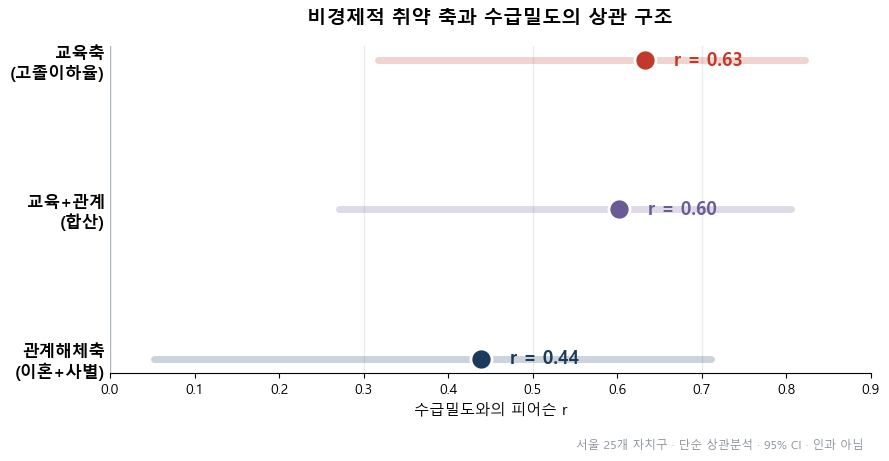

[차트4] 03_axis_v4_forest.png 저장
  교육축: r = 0.632
  교육+관계: r = 0.602
  관계해체축: r = 0.438


In [107]:
# 차트 4: 축별 분해 — 포레스트 플롯형 점도표
# ============================================================

z_edu = (prof["고졸이하율"] - prof["고졸이하율"].mean()) / prof["고졸이하율"].std()
z_div = (prof["이혼율"] - prof["이혼율"].mean()) / prof["이혼율"].std()
z_ber = (prof["사별율"] - prof["사별율"].mean()) / prof["사별율"].std()

z_rel = z_div + z_ber
z_total = z_edu + z_rel

r_edu = np.corrcoef(z_edu, prof["수급밀도"])[0, 1]
r_rel = np.corrcoef(z_rel, prof["수급밀도"])[0, 1]
r_total = np.corrcoef(z_total, prof["수급밀도"])[0, 1]

# Fisher z 변환 기반 95% 신뢰구간
def pearson_ci(r, n, zcrit=1.96):
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    lo = np.tanh(z - zcrit * se)
    hi = np.tanh(z + zcrit * se)
    return lo, hi

n = len(prof)

rows = pd.DataFrame({
    "axis": ["교육축\n(고졸이하율)", "교육+관계\n(합산)", "관계해체축\n(이혼+사별)"],
    "r": [r_edu, r_total, r_rel],
    "color": ["#C0392B", "#6B5B95", "#1B3A5C"]
})

rows[["ci_low", "ci_high"]] = rows["r"].apply(
    lambda r: pd.Series(pearson_ci(r, n))
)

# 보여주고 싶은 순서 고정: 강한 것부터
rows = rows.sort_values("r", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.8), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

ypos = np.arange(len(rows))

# 기준선
for xline in [0.3, 0.5, 0.7]:
    ax.axvline(xline, color="#E9ECEF", lw=1, zorder=0)

ax.axvline(0, color="#ADB5BD", lw=1)

# 신뢰구간 + 점
for i, row in rows.iterrows():
    ax.plot(
        [row["ci_low"], row["ci_high"]],
        [i, i],
        color=row["color"],
        lw=5,
        alpha=0.22,
        solid_capstyle="round",
        zorder=2
    )
    ax.scatter(
        row["r"],
        i,
        s=230,
        color=row["color"],
        edgecolors="white",
        linewidth=2,
        zorder=3
    )
    ax.text(
        row["r"] + 0.035,
        i,
        f"r = {row['r']:.2f}",
        va="center",
        ha="left",
        fontsize=13,
        fontweight="bold",
        color=row["color"]
    )

ax.set_yticks(ypos)
ax.set_yticklabels(rows["axis"], fontsize=12, fontweight="bold")
ax.set_xlim(0, 0.9)
ax.set_xlabel("수급밀도와의 피어슨 r", fontsize=11)

ax.set_title(
    "비경제적 취약 축과 수급밀도의 상관 구조",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0.99,
    -0.20,
    "서울 25개 자치구 · 단순 상관분석 · 95% CI · 인과 아님",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8.5,
    color="#868E96"
)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(False)

plt.tight_layout()
plt.savefig(
    f"{OUT_DIR}/03_axis_v4_forest.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)
plt.show()

print("[차트4] 03_axis_v4_forest.png 저장")
print(f"  교육축: r = {r_edu:.3f}")
print(f"  교육+관계: r = {r_total:.3f}")
print(f"  관계해체축: r = {r_rel:.3f}")

---
## 정리

**[확정 사실]** 서울의 5060 남성 1인가구는 취업해도 단순노무 전국 1위로 일자리 질이 가장 낮고,
교육·관계해체 취약성은 서울 전역에 고르지 않고 동북권 일부 자치구에 집중된다.
이 패턴은 생계급여 수급밀도와도 단조 증가 관계를 보이며,
교육축(r=0.63)과 관계해체축(r=0.44) 모두 독립적으로 경제적 취약과 연동된다.

**[남는 질문]** 이들은 가장 인프라가 촘촘한 도시 한복판에 있으면서도
일상의 접점이 서서히 사라진 자리에 놓여 있다.
가장 편리하고 제도화된 도시 서울의 생활 환경은 이 고립을 완화하는가, 아니면 보이지 않게 유지시키는가?

### 한계
- 2020 인구총조사(1인가구)와 2024 수급자 데이터는 연도가 다르다.
- 취약 점수·등급은 3개 지표 단순 합산의 탐색적 분류이며 인과·예측이 아니다.
- 표본 25개 — 통계적 유의성 검정에 충분한 표본이 아니다.
- 상관은 인과가 아니다.

### 다음 단계 인계
- **4단계(위험자 발굴)**: 취약성이 특정 자치구에 집중, 행정 지표(수급밀도)와 맞물림
- **5단계(서울의 역설)**: 취약하지만 보이지 않는다 → 도시 한복판에서 일상의 접점이 사라진 이유